In [60]:
# Importacion de librerias
import os # para manejar rutas de archivos
import jax
import numpy as np
import kagglehub # para descargar el dataset
import pandas as pd # para el manejo de datos
import jax.numpy as jnp # para el manejo de datos con jax
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # para dividir el dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # para evaluar el modelo de clasificacion
import seaborn as sns # para visualizar las matrices de confusión

In [61]:
# cargo de dataset y EDA
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
df = pd.read_csv(os.path.join(path, "healthcare-dataset-stroke-data.csv"))

In [62]:
print("\n Datos Iniciales")
display(df.head())


 Datos Iniciales


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [63]:
print(f"\n tamaño del Dataset {df.shape}")


 tamaño del Dataset (5110, 12)


In [64]:
print("Tipos de datos")
df.info()

Tipos de datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [65]:
print("\nDescripcion del Dataset ")
display(df.describe().round(2))



Descripcion del Dataset 


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00


### Deteccion de valores aberrantes en variables numericas (Gráfica de caja y bigotes)



Variables numericas analizadas: 3
['age', 'avg_glucose_level', 'bmi']


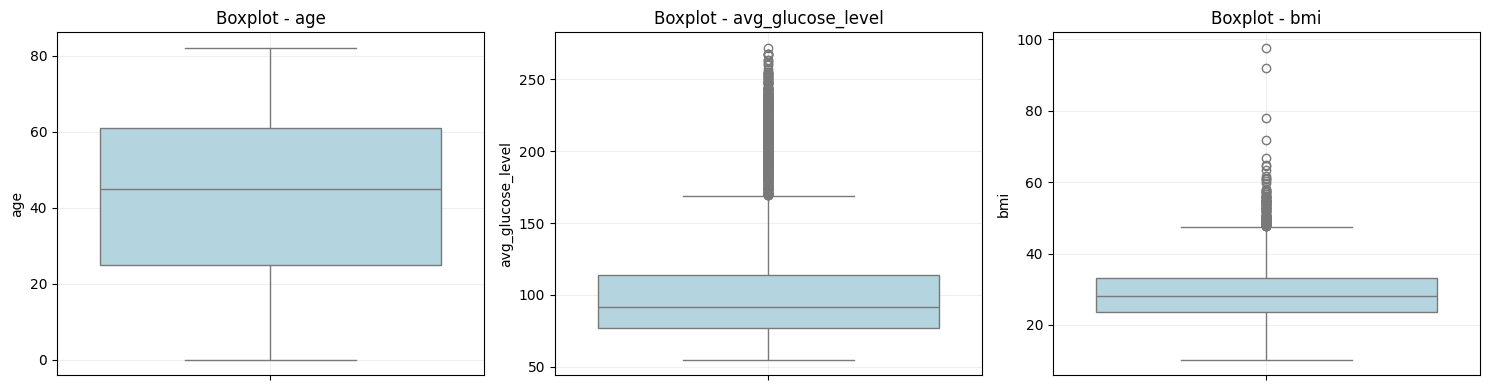

In [66]:
numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
numeric_cols_no_target = [col for col in numeric_cols if col != target_col] if 'target_col' in locals() else [c for c in numeric_cols if c != 'stroke']

print(f"\nVariables numericas analizadas: {len(numeric_cols_no_target)}")
print(numeric_cols_no_target)

if numeric_cols_no_target:
    n_cols = 3
    n_rows = (len(numeric_cols_no_target) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols_no_target):
        sns.boxplot(y=df[col], ax=axes[idx], color='lightblue')
        axes[idx].set_title(f'Boxplot - {col}')
        axes[idx].set_xlabel('')
        axes[idx].grid(alpha=0.2)

    for idx in range(len(numeric_cols_no_target), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron variables numericas para analizar outliers.")



Variables numéricas analizadas: 3
['age', 'avg_glucose_level', 'bmi']


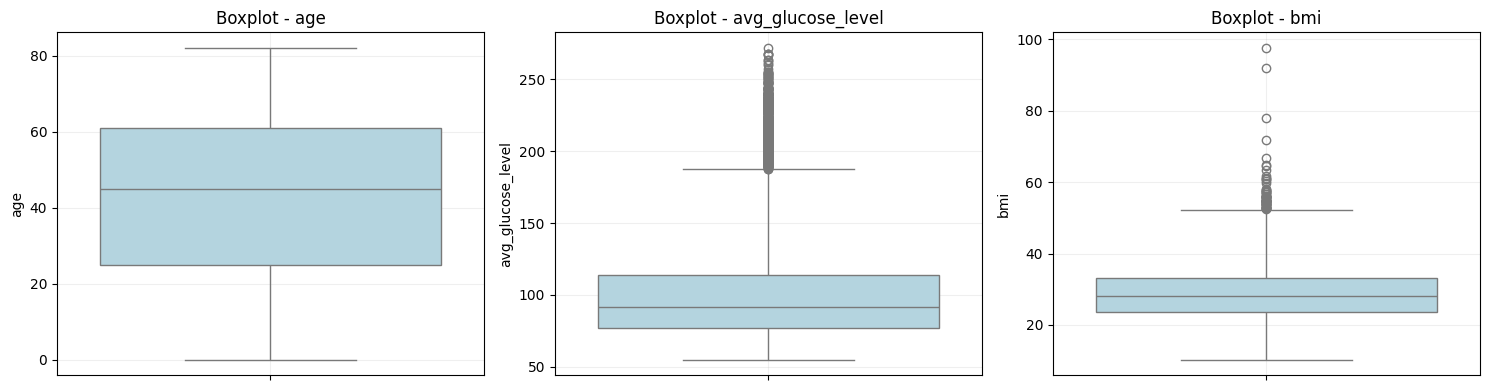

In [67]:
def plot_boxplots(df, target_col='stroke'):
    """
    Identifica las variables numéricas en el DataFrame (excluyendo la variable objetivo)
    y genera boxplots para analizar visualmente la presencia de valores atípicos.
    """
    numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
    
    if target_col in df.columns:
        numeric_cols_no_target = [col for col in numeric_cols if col != target_col]
    else:
        # Por si se proporciona un dataset sin la variable objetivo
        numeric_cols_no_target = numeric_cols

    print(f"\nVariables numéricas analizadas: {len(numeric_cols_no_target)}")
    print(numeric_cols_no_target)

    if numeric_cols_no_target:
        n_cols = 3
        # Calculamos la cantidad de filas necesarias para nuestra cuadrícula de subplots
        n_rows = (len(numeric_cols_no_target) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
        
        # Aplanamos los ejes para manejarlos fácilmente en un solo bucle iterativo
        if n_rows * n_cols > 1:
            axes = axes.flatten()
        else:
            axes = [axes] # En caso de que haya una sola gráfica

        for idx, col in enumerate(numeric_cols_no_target):
            sns.boxplot(y=df[col], 
                        ax=axes[idx], 
                        whis=2, # aumentamos a 2 veces el IQR para detectar valores aberrantes
                        color='lightblue')
            axes[idx].set_title(f'Boxplot - {col}')
            axes[idx].set_xlabel('')
            axes[idx].grid(alpha=0.2)

        # Eliminamos los subplots sobrantes o vacíos si los hay
        for idx in range(len(numeric_cols_no_target), len(axes)):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        plt.show()
    else:
        print("No se encontraron variables numéricas para analizar outliers.")

# Llamada inicial antes o después de la remoción de outliers:
plot_boxplots(df, target_col='stroke')


In [68]:
# Eliminar valores atípicos de bmi > 55
# Retenemos también los valores nulos para no perderlos antes de la imputación
df = df[(df['bmi'] <= 55) | (df['bmi'].isna())]
print(f"Tamaño del dataset después de eliminar valores atípicos de bmi: {df.shape}")

Tamaño del dataset después de eliminar valores atípicos de bmi: (5077, 12)



Variables numéricas analizadas: 3
['age', 'avg_glucose_level', 'bmi']


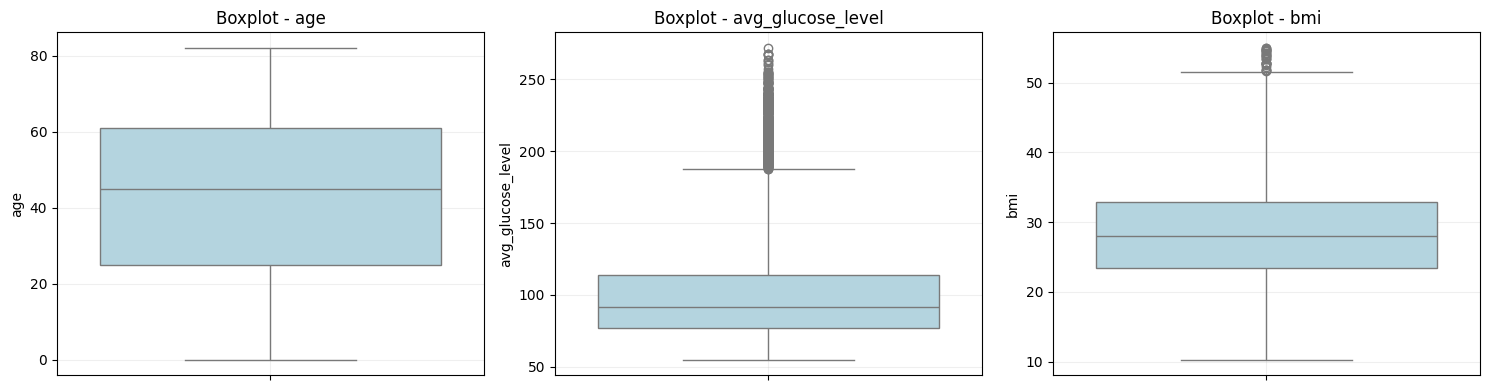

In [69]:
plot_boxplots(df, target_col='stroke')


-Revision de valores faltantes


,Faltantes conteo,Faltantes %
bmi,201,3.96
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00



Balance de la columna objetivo correspondiente a si el paciente tendrá un derrame (Stroke)
Proporciones:
 stroke
0    95.1
1     4.9
Name: proportion, dtype: float64

Conteos:
 stroke
0    4829
1     248
Name: count, dtype: int64


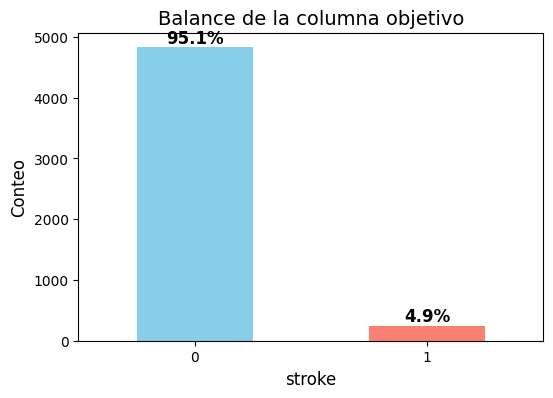

In [70]:
print("\n-Revision de valores faltantes")
missing_data = pd.DataFrame({
    'Faltantes conteo': df.isna().sum(),
    'Faltantes %': (df.isnull().sum() / len(df)) * 1e2
}).sort_values(by='Faltantes conteo', ascending=False) # los ordenamos en orden descendente para ver primero los que tienen mas faltantes
display(missing_data.round(2))

print("\nBalance de la columna objetivo correspondiente a si el paciente tendrá un derrame (Stroke)")
target_col = 'stroke' # la columna objetivo
print("Proporciones:\n", df[target_col].value_counts(normalize=True).round(3) * 100)
print("\nConteos:\n", df[target_col].value_counts())

# Graficando el balance de la columna objetivo
plt.figure(figsize=(6, 4))
ax = df[target_col].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Balance de la columna objetivo', fontsize=14)
plt.xlabel(target_col, fontsize=12)
plt.ylabel('Conteo', fontsize=12)
plt.xticks(rotation=0)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()


Como está muy desbalanceado, al momento de hacer nuestra division de datos, vamos a usar la tecnica de estratificacion para asegurarnos que tanto el conjunto de entrenamiento como el de prueba tengan una representacion proporcional de ambas clases (stroke = 0 y stroke = 1).
Asimismo, dado que el dataset tiene una cantidad limitada de muestras, vamos a usar la tecnica de validacion cruzada para evaluar nuestro modelo de manera mas robusta y evitar problemas de sobreajuste.
Lo más importante de nuestro modelo es evitar los falsos negativos (FN), es decir, casos donde el modelo predice que un paciente no tendrá un derrame (stroke = 0) cuando en realidad sí lo tendrá (stroke = 1). Esto es crucial porque un falso negativo podría llevar a la falta de atención médica necesaria para un paciente que realmente está en riesgo de sufrir un derrame. Por lo tanto, vamos a enfocarnos en maximizar el recall (sensibilidad) de nuestro modelo, ya que esta métrica nos indica qué tan bien el modelo identifica correctamente los casos positivos (stroke = 1). Sin embargo, también debemos tener en cuenta el precision para evitar demasiados falsos positivos (FP), donde el modelo predice que un paciente tendrá un derrame cuando en realidad no lo tendrá. Por eso, utilizaremos el F1-score como una métrica balanceada que considera tanto el precision como el recall.

Métricas importantes:

F1-score:

$F1-score= 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$

Precision:

$Precision = \frac{TP}{TP + FP}$

Recall:

$Recall = \frac{TP}{TP + FN}$

Donde:

TP (True Positives): Verdaderos positivos, el número de casos correctamente predichos como positivos (stroke = 1).
FP (False Positives): Falsos positivos, el número de casos incorrectamente predichos como positivos (stroke = 1 cuando en realidad es 0).
FN (False Negatives): Falsos negativos, el número de casos incorrectamente predichos como negativos (stroke = 0 cuando en realidad es 1).

### Feature Engineering: Explicación de las variables creadas

En el proceso de preparación de datos, se generan nuevas variables para mejorar la capacidad predictiva de los modelos. Estas variables son:

- **is_senior**: Variable binaria que indica si el paciente tiene más de 70 años (`1` si la edad es mayor a 70, `0` en caso contrario). Se utiliza porque la edad avanzada es un factor de riesgo importante para accidentes cerebrovasculares.

- **bmi_cat**: Categorización del índice de masa corporal (BMI) en cuatro grupos: 'Underweight' (bajo peso, BMI < 18.5), 'Normal' (18.5 ≤ BMI < 25), 'Overweight' (25 ≤ BMI < 30) y 'Obese' (BMI ≥ 30). Esta variable permite capturar riesgos asociados a diferentes rangos de peso.

- **comorbidity_index**: Suma de las variables `hypertension` y `heart_disease`. Representa un índice de comorbilidad cardiovascular, donde valores más altos indican mayor presencia de condiciones que aumentan el riesgo de stroke.

- **smoking_risk**: Variable binaria que indica riesgo combinado por tabaquismo. Toma el valor `1` si el paciente tiene más de 50 años y fuma actualmente o fumó anteriormente, y `0` en caso contrario. Se basa en la evidencia de que el tabaquismo en edades avanzadas incrementa el riesgo de eventos cerebrovasculares.

Estas variables enriquecen el conjunto de datos original y ayudan a los modelos a identificar patrones de riesgo más complejos y relevantes para la predicción de accidentes cerebrovasculares.


In [71]:
class DataPreprocessor:
    def __init__(self, umbral=0.5):
        self.umbral = umbral
        self.mu_x, self.sigma_x = None, None

    def prepare_data(self, df, target_col, test_size=0.2, random_state=42):
        df_clean = df.copy()
        if 'id' in df_clean.columns:
            df_clean = df_clean.drop(columns=['id'])

        # Imputación generalizada para cualquier columna numérica
        numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
        for col in numeric_cols:
            if df_clean[col].isna().any():
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())

        # Imputación generalizada para cualquier columna categórica
        cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
        for col in cat_cols:
            if df_clean[col].isna().any():
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

        #FEATURE ENGINEERING
        # 1. Riesgo por edad avanzada (Senior)
        df_clean['is_senior'] = (df_clean['age'] >= 70).astype(float)
        
        # 2. Categorización por BMI (bajo peso, normal, sobrepeso, obeso)
        def categorize_bmi(bmi):
            if bmi < 18.5: return 'Underweight'
            if bmi < 25: return 'Normal'
            if bmi < 30: return 'Overweight'
            return 'Obese'
        df_clean['bmi_cat'] = df_clean['bmi'].apply(categorize_bmi)
        
        # 3. Índice de comorbilidad cardiovascular
        df_clean['comorbidity_index'] = df_clean['hypertension'] + df_clean['heart_disease']
        
        # 4. Riesgo combinado por tabaquismo (Edad > 50 y fuma o fumo anteriormente)
        df_clean['smoking_risk'] = ((df_clean['age'] > 50) & 
                                   (df_clean['smoking_status'].isin(['smokes', 'formerly smoked']))).astype(float)
        # --------------------------------------------

        X = df_clean.drop(columns=[target_col])
        y = df_clean[target_col].values.reshape(-1, 1)

        X_encoded = pd.get_dummies(X, drop_first=True, dtype=float)

        self.mu_x, self.sigma_x = X_encoded.mean().values, X_encoded.std().values
        self.sigma_x = jnp.where(self.sigma_x == 0, 1.0, self.sigma_x)
        X_norm = (X_encoded.values - self.mu_x) / self.sigma_x

        y_array = jnp.array(y, dtype=jnp.float32)

        ones = jnp.ones((X_norm.shape[0], 1), dtype=jnp.float32)
        X_b = jnp.hstack([X_norm, ones])

        return train_test_split(X_b, y_array,
                                test_size=test_size,
                                stratify=y_array, random_state=random_state)


In [72]:
# Regresión Lineal
class LinearRegressionJAX:
    def __init__(self, preprocessor):
        self.theta = None
        self.preprocessor = preprocessor # el preprocesador es necesario para poder normalizar los datos de entrada antes de hacer las predicciones, esto es importante porque el modelo fue entrenado con datos normalizados, si no normalizamos los datos de entrada antes de hacer las predicciones, el modelo no funcionará correctamente y las predicciones serán incorrectas.

    def train(self, X_train, y_train):
        XT = X_train.T
        self.theta = jnp.linalg.solve(jnp.dot(XT, X_train), jnp.dot(XT, y_train)) # esta es la ecuacion normal para resolver el problema de minimos cuadrados en regresion lineal,nos da los coeficientes optimos (theta) que minimizan la funcion de costo de minimos cuadrados,al tomar la derivada de la funcion de costo con respecto a theta e igualarla a cero para encontrar el minimo, eficiente para conjuntos de datos pequeños a medianos, pero puede ser computacionalmente costosa para conjuntos de datos muy grandes debido a la inversion de matrices, sin embargo, en este caso nuestro dataset es pequeño

    def predict(self, X_data):
        y_pred = jnp.dot(X_data, self.theta)
        return y_pred

In [73]:
@jax.jit # esta decoracion de jax.jit compila la funcion para que se ejecute de manera mas eficiente, importante en el caso de la regresion logistica donde se realizan muchas iteraciones de entrenamiento y calculo de gradientes, al compilar la funcion con jax.jit, podemos acelerar significativamente el proceso de entrenamiento y hacer que el modelo sea mas rapido y eficiente.
def sigmoid(z):
    return 1.0 / (1.0 + jnp.exp(-z)) # esta es la funcion sigmoide, que es la funcion de activacion utilizada en la regresion logistica para mapear las predicciones lineales a un rango entre 0 y 1.

def compute_weighted_bce_loss(theta, X, y, pos_weight):
    predictions = sigmoid(jnp.dot(X, theta)) # aplicamos la funcion de sigmoide a la multiplicacion de X por theta para obtener las probabilidades predichas por el modelo, esto es necesario porque la funcion de costo de entropia cruzada binaria (BCE) se calcula en base a las probabilidades predichas por el modelo, y la funcion sigmoide nos permite convertir las predicciones lineales a probabilidades entre 0 y 1, lo cual es esencial para calcular correctamente la perdida de BCE.
    epsilon = 1e-15 # usamos un valor muy cercano a cero para evitar problemas de logaritmo de cero en el calculo de la perdida, esto porque si las predicciones son exactamente 0 o 1, el logaritmo de estas predicciones puede ser indefinido, lo que resultaria en NaN
    loss = -jnp.mean(pos_weight * y * jnp.log(predictions + epsilon) + 1.0 * (1 - y) * jnp.log(1 - predictions + epsilon)) # la pérdida ponderdada donde pos_weight solo multiplica al error cuando y=1, esto es porque queremos minimizar los falsos negativos. Añadimos epsilon a las predicciones.
    return loss

@jax.jit
def update_step_weighted(theta, X, y, learning_rate, pos_weight):
    loss, gradients = jax.value_and_grad(compute_weighted_bce_loss)(theta, X, y, pos_weight) #con el metodo value_and_grad de jax, podemos calcular tanto la perdida como los gradientes, lo que sirve para el proceso de entrenamiento del modelo de regresion logistica, ya que necesitamos calcular la perdida para evaluar el rendimiento del modelo y los gradientes para actualizar los pesos (theta) del modelo en cada iteracion de entrenamiento.
    new_theta = theta - learning_rate * gradients # acá actualizamos multiplicando por el learning_rate para controlar la magnitud de la actualización, esto es importante para asegurar que el modelo converja de manera estable hacia los pesos óptimos, evitando actualizaciones demasiado grandes que podrían hacer que el modelo diverja o actualizaciones demasiado pequeñas que podrían hacer que el proceso de entrenamiento sea muy lento.
    return new_theta, loss

class LogisticRegressionJAX:
    def __init__(self, preprocessor, learning_rate=0.1, epochs=1000):
        self.preprocessor = preprocessor
        self.learning_rate = learning_rate
        self.epochs = epochs # numero de iteraciones de entrenamiento, las veces que vamos a actualizar los pesos del modelo utilizando el descenso de gradiente, un numero mayor de epochs puede permitir que el modelo aprenda mejor los patrones en los datos, pero también puede aumentar el riesgo de sobreajuste si se entrena por demasiado tiempo.
        self.theta = None
        self.pos_weight = 1.0 # por defecto no hay peso de preferencia para castigar los falsos negativos

    def train(self, X_train, y_train):
        n_features = X_train.shape[1]
        self.theta = jnp.zeros((n_features, 1)) # inicializamos los pesos (theta) del modelo con ceros, esto es un punto de partida común para el entrenamiento de modelos de regresion logistica, ya que permite que el modelo comience a aprender desde un estado neutral sin sesgo inicial hacia ninguna clase, y luego se actualizan iterativamente durante el proceso de entrenamiento utilizando el descenso de gradiente para encontrar los pesos óptimos que minimizan la función de costo de entropía cruzada binaria ponderada.

        num_zeros = jnp.sum(y_train == 0) # calculamos el numero de casos negativos (stroke = 0)
        num_ones = jnp.sum(y_train == 1) # para cuando stroke = 1
        self.pos_weight = num_zeros / num_ones # con esta relación calculamos el peso para la clase positiva (stroke = 1), esto es importante porque al tener un dataset desbalanceado, queremos darle más peso a los casos positivos para que el modelo preste más atención a ellos durante el entrenamiento, lo que puede ayudar a mejorar el recall y reducir los falsos negativos.
        print(f"Peso para la clase positiva de la regresión Logística: {self.pos_weight:.2f}")

        for epoch in range(self.epochs):
            self.theta, loss = update_step_weighted(self.theta, X_train, y_train, self.learning_rate, self.pos_weight) # acá utilizamos el método de actualización ponderada para actualizar los pesos del modelo en cada iteración de entrenamiento

        print("Modelo logístico ponderado entrenado por Gradiente Descendiente.")

    def predict_proba(self, X_data):
        return sigmoid(jnp.dot(X_data, self.theta)) # esta función calcula las probabilidades predichas por el modelo para cada muestra en X_data, al aplicar la función sigmoide a la multiplicación de X_data por los pesos (theta) del modelo, obtenemos las probabilidades de que cada muestra pertenezca a la clase positiva (stroke = 1), estas probabilidades se utilizan posteriormente para hacer predicciones binarias basadas en un umbral de decisión.

    def predict(self, X_data):
        probabilities = self.predict_proba(X_data)
        return (probabilities >= self.preprocessor.umbral).astype(int) # con probabilites >= umbral, convertimos las probabilidades a predicciones binarias (0 o 1), esto es, lo discretizamos en función de un umbral de decisión, donde si la probabilidad predicha es mayor o igual al umbral, se predice la clase positiva (1), y si es menor, se predice la clase negativa (0). El valor del umbral puede ser ajustado para optimizar el balance entre precision y recall según las necesidades del problema.

---
### función de Entropía Cruzada Binaria (BCE) Ponderada

Esta función calcula la **Pérdida de Entropía Cruzada Binaria Ponderada**, que sirve como el objetivo de optimización para el modelo de regresión logística. Al introducir un parámetro de peso, obliga matemáticamente al proceso de descenso de gradiente a penalizar los falsos negativos (casos omitidos de accidente cerebrovascular) con mucha más severidad que los falsos positivos.

#### 1. La Combinación Lineal
Primero, el modelo calcula la combinación lineal ($Z$) mediante el producto punto de las características del paciente ($X$) y los pesos actuales del modelo ($\theta$):
$$Z = \theta_0 +\theta_1\cdot x_1 + \theta_2\cdot x_2+...\theta_n\cdot x_n = X \cdot \theta$$

El problema es que el rango de Z va desde \$-\infty$ a $+\infty$, lo que no es adecuado para la clasificación binaria, ya que necesitamos una salida que represente una probabilidad entre 0 y 1.

#### 2. La Activación Sigmoide
El puntaje crudo se pasa a través de la función Sigmoide para comprimir los valores continuos a una probabilidad predicha ($\hat{y}$) entre $0.0$ y $1.0$:
$$\hat{y} = \sigma(Z) = \frac{1}{1 + e^{-Z}}$$

#### 3. La Ecuación de Pérdida Ponderada
Finalmente, la pérdida ($L$) se calcula sobre los $N$ pacientes. El ajuste crítico aquí es $w_{pos}$ (`pos_weight`). Este peso se aplica **únicamente** a los casos reales de accidente cerebrovascular ($y_i = 1$). Si el modelo predice una probabilidad baja para un paciente real, el gran error resultante se multiplica por $w_{pos}$ (ej., 19.0), aumentando una penalización mayor en el gradiente para corregir los pesos.

$$L = -\frac{1}{N} \sum_{i=1}^{N} \left[ w_{pos} \cdot y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]$$

---

In [74]:
class SimpleFastDecisionTree:
    def __init__(
        self,
        max_depth: int = 6,
        min_samples_split: int = 20,
        min_samples_leaf: int = 8,
        n_thresholds: int = 16,
        pos_weight: float = 1.0,
        prediction_threshold: float = 0.40,
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.n_thresholds = n_thresholds
        self.pos_weight = pos_weight
        self.prediction_threshold = prediction_threshold
        self.tree = None

    def _sample_weights(self, y):
        return np.where(y == 1, self.pos_weight, 1.0)

    def _gini_impurity_weighted(self, y):
        if len(y) == 0:
            return 0.0
        w = self._sample_weights(y)
        p1 = np.sum(w * y) / np.sum(w)
        return float(1.0 - (p1**2 + (1.0 - p1) ** 2))

    def _leaf_payload(self, y):
        w = self._sample_weights(y)
        prob = float(np.sum(w * y) / np.sum(w))
        return {
            'type': 'leaf',
            'probability': prob,
            'prediction': int(prob >= self.prediction_threshold),
            'samples': int(len(y)),
        }

    def _candidate_thresholds(self, feature_values):
        quantiles = np.linspace(0.05, 0.95, self.n_thresholds)
        thresholds = np.quantile(feature_values, quantiles)
        return np.unique(thresholds)

    def _find_best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_gini = self._gini_impurity_weighted(y)
        best_gain = 0.0
        best_feature = None
        best_threshold = None

        for feature_idx in range(n_features):
            thresholds = self._candidate_thresholds(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                n_left = int(np.sum(left_mask))
                n_right = int(np.sum(right_mask))
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                gini_left = self._gini_impurity_weighted(y_left)
                gini_right = self._gini_impurity_weighted(y_right)

                child_gini = (n_left / n_samples) * gini_left + (n_right / n_samples) * gini_right
                gain = parent_gini - child_gini

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = float(threshold)

        return best_feature, best_threshold

    def _build_tree_recursive(self, X, y, depth=0):
        n_samples = len(y)
        if (
            depth >= self.max_depth
            or n_samples < self.min_samples_split
            or len(np.unique(y)) == 1
        ):
            return self._leaf_payload(y)

        best_feature, best_threshold = self._find_best_split(X, y)
        if best_feature is None:
            return self._leaf_payload(y)

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        left_tree = self._build_tree_recursive(X[left_mask], y[left_mask], depth + 1)
        right_tree = self._build_tree_recursive(X[right_mask], y[right_mask], depth + 1)

        return {
            'type': 'node',
            'feature': int(best_feature),
            'threshold': best_threshold,
            'left': left_tree,
            'right': right_tree,
        }

    def fit(self, X, y):
        print("Training weighted Decision Tree...")
        # FIX: Convertimos a NumPy nativo para evitar cuellos de botella recursivos con JAX Tracers
        X_np = np.array(X)
        y_flat = np.array(y).flatten().astype(int)
        self.tree = self._build_tree_recursive(X_np, y_flat)
        print("Training completed!")

    def _predict_one(self, x, tree):
        proba = self._predict_one_proba(x, tree)
        return int(proba >= self.prediction_threshold)

    def _predict_one_proba(self, x, tree):
        if tree['type'] == 'leaf':
            return float(tree['probability'])
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_one_proba(x, tree['left'])
        return self._predict_one_proba(x, tree['right'])

    def predict_proba(self, X):
        if self.tree is None:
            raise ValueError("Tree not trained yet!")
        X_np = np.array(X)
        probs = [self._predict_one_proba(X_np[i], self.tree) for i in range(len(X_np))]
        return jnp.array(probs, dtype=jnp.float32).reshape(-1, 1)

    def predict(self, X):
        if self.tree is None:
            raise ValueError("Tree not trained yet!")
        X_np = np.array(X)
        preds = [self._predict_one(X_np[i], self.tree) for i in range(len(X_np))]
        return jnp.array(preds, dtype=jnp.int32)

In [75]:
# %% Multilayer Perceptron JAX (Versión Robusta)
@jax.jit
def relu(x):
    return jnp.maximum(0, x)

def compute_mlp_weighted_bce_loss(params, X, y, pos_weight):
    W1, b1, W2, b2 = params
    Z1 = jnp.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = jnp.dot(A1, W2) + b2
    # Usamos jax.nn.sigmoid para mayor estabilidad numérica
    predictions = jax.nn.sigmoid(Z2)
    epsilon = 1e-7  # epsilon un poco mayor para evitar NaNs en gradientes
    loss = -jnp.mean(pos_weight * y * jnp.log(predictions + epsilon) + (1 - y) * jnp.log(1 - predictions + epsilon))
    return loss

@jax.jit
def update_mlp_step_weighted(params, X, y, learning_rate, pos_weight):
    loss, gradients = jax.value_and_grad(compute_mlp_weighted_bce_loss)(params, X, y, pos_weight)
    
    W1, b1, W2, b2 = params
    dW1, db1, dW2, db2 = gradients
    
    # Clip gradients para evitar explosiones
    dW1 = jnp.clip(dW1, -1.0, 1.0)
    dW2 = jnp.clip(dW2, -1.0, 1.0)
    
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    return (W1, b1, W2, b2), loss

class MultilayerPerceptronJAX:
    def __init__(self, preprocessor, hidden_size=16, learning_rate=0.01, epochs=2000):
        self.preprocessor = preprocessor
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.params = None
        self.pos_weight = 1.0
        
    def train(self, X_train, y_train):
        n_features = X_train.shape[1]
        
        key = jax.random.PRNGKey(42)
        k1, k2, k3, k4 = jax.random.split(key, 4)
        # Inicialización de Xavier/Glorot mejorada
        limit1 = jnp.sqrt(6.0 / (n_features + self.hidden_size))
        W1 = jax.random.uniform(k1, (n_features, self.hidden_size), minval=-limit1, maxval=limit1)
        b1 = jnp.zeros((self.hidden_size,))
        
        limit2 = jnp.sqrt(6.0 / (self.hidden_size + 1))
        W2 = jax.random.uniform(k3, (self.hidden_size, 1), minval=-limit2, maxval=limit2)
        b2 = jnp.zeros((1,))
        
        self.params = (W1, b1, W2, b2)
        
        num_zeros = jnp.sum(y_train == 0)
        num_ones = jnp.sum(y_train == 1)
        self.pos_weight = float(num_zeros / jnp.maximum(num_ones, 1))
        print(f"Peso para la clase positiva del MLP: {self.pos_weight:.2f}")
        
        for epoch in range(self.epochs):
            self.params, loss = update_mlp_step_weighted(self.params, X_train, y_train, self.learning_rate, self.pos_weight)
            if epoch % 500 == 0:
                print(f"  Epoch {epoch}, Loss: {float(loss):.4f}")
            
        print("Multilayer Perceptron entrenado exitosamente.")
        
    def predict_proba(self, X_data):
        W1, b1, W2, b2 = self.params
        Z1 = jnp.dot(X_data, W1) + b1
        A1 = relu(Z1)
        Z2 = jnp.dot(A1, W2) + b2
        return jax.nn.sigmoid(Z2)
        
    def predict(self, X_data):
        probabilities = self.predict_proba(X_data)
        return (probabilities >= self.preprocessor.umbral).astype(int)


### AdaBoost
AdaBoost es un algoritmo de *ensemble* (ensamble) que combina múltiples
clasificadores "débiles" (weak learners) para formar un clasificador
"fuerte". La idea central es:
1. Entrenar un clasificador débil (en nuestro caso, un Decision Stump,
 que es un árbol de decisión con profundidad = 1).
 2. Calcular su error ponderado. Las muestras mal clasificadas reciben
    mayor peso para que el siguiente clasificador se enfoque en ellas.
   3. Repetir T veces. La predicción final es un voto ponderado de todos
      los clasificadores débiles.

 Fórmulas:
   - Error ponderado:  $ε_t = Σ w_i * I(y_i ≠ h_t(x_i))$
   - Peso del clasificador:  $α_t = 0.5 * ln((1 - ε_t) / ε_t)$
   - Actualización de pesos: $w_i = w_i * exp(-α_t * y_i * h_t(x_i))$
     (luego se normalizan para que sumen 1)
   - Predicción final:  $H(x) = sign( Σ α_t * h_t(x) )$

In [76]:
class AdaBoostJAX:
    """
    Implementación de AdaBoost para clasificación binaria.
    Utiliza clasificadores heterogéneos (Decision Tree, Logistic, Linear, MLP).
    
    Parámetros:
    -----------
    n_estimators : int
        Número de clasificadores débiles a entrenar.
    """
    def __init__(self, preprocessor=None, n_estimators=12):
        self.n_estimators = n_estimators
        self.preprocessor = preprocessor
        self.models = []

    def fit(self, X, y):
        """
        Entrena el modelo AdaBoost con clasificadores heterogéneos mediante remuestra.
        """
        X_np = np.array(X)
        y_np = np.array(y).flatten()
        n_samples = X_np.shape[0]
        
        y_converted = np.where(y_np == 0, -1, 1)
        
        n_pos = np.sum(y_np == 1)
        n_neg = np.sum(y_np == 0)
        weights = np.where(y_np == 1, 1.0 / (2 * n_pos), 1.0 / (2 * n_neg))
        weights = weights / np.sum(weights)
        
        self.models = []
        
        # Si preprocessor es None, intentamos usar el global 'processor'
        proc = self.preprocessor if self.preprocessor is not None else processor
        
        for t in range(self.n_estimators):
            model_type = t % 4
            
            # Resampling basado en los pesos
            indices = np.random.choice(n_samples, size=n_samples, replace=True, p=weights)
            X_sample = X_np[indices]
            y_sample = y_np[indices]
            
            #aca elegimos los modelos debilos
            if model_type == 0:
                model = SimpleFastDecisionTree(max_depth=3, n_thresholds=10)
                model.fit(X_sample, y_sample)
            elif model_type == 1:
                model = LogisticRegressionJAX(preprocessor=proc, learning_rate=0.01, epochs=200)
                model.train(X_sample, y_sample)
            elif model_type == 2:
                model = LinearRegressionJAX(preprocessor=proc)
                model.train(X_sample, y_sample)
            elif model_type == 3:
                model = MultilayerPerceptronJAX(preprocessor=proc, hidden_size=8, learning_rate=0.01, epochs=200)
                model.train(X_sample, y_sample)
            
            # Generar predicciones sobre el dataset original
            if model_type == 2:
                preds = model.predict(X_np).flatten()
                predictions = np.where(preds >= 0.5, 1, -1)
            elif model_type == 0:
                preds = model.predict(X_np).flatten()
                predictions = np.where(preds == 1, 1, -1)
            else:
                preds = model.predict_proba(X_np).flatten()
                predictions = np.where(preds >= 0.5, 1, -1)
            
            misclassified = predictions != y_converted
            weighted_error = np.dot(weights, misclassified)
            
            if weighted_error >= 0.5:
                weighted_error = 0.5 - 1e-10

            epsilon = 1e-10
            alpha = 0.5 * np.log((1.0 - weighted_error + epsilon) / (weighted_error + epsilon))
            
            weights = weights * np.exp(-alpha * y_converted * predictions)
            weights = weights / np.sum(weights)
            
            self.models.append((model, alpha, model_type))
            
        print(f"AdaBoost entrenado con {self.n_estimators} modelos heterogéneos.")

    def predict_score(self, X):
        X_np = np.array(X)
        n_samples = X_np.shape[0]
        
        scores = np.zeros(n_samples)
        for model, alpha, model_type in self.models:
            if model_type == 2:
                preds = model.predict(X_np).flatten()
                predictions = np.where(preds >= 0.5, 1, -1)
            elif model_type == 0:
                preds = model.predict(X_np).flatten()
                predictions = np.where(preds == 1, 1, -1)
            else:
                preds = model.predict_proba(X_np).flatten()
                predictions = np.where(preds >= 0.5, 1, -1)
                
            scores += alpha * predictions
            
        return scores

    def predict_proba(self, X):
        scores = self.predict_score(X)
        return 1.0 / (1.0 + np.exp(-scores))

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

    def get_stump_data(self):
        return []


Preparando los datos...


Entrenando Clasificador Lineal...
Entrenando Clasificador Logístico Ponderado...
Peso para la clase positiva de la regresión Logística: 19.51
Modelo logístico ponderado entrenado por Gradiente Descendiente.
Entrenando Multilayer Perceptron...
Peso para la clase positiva del MLP: 19.51
  Epoch 0, Loss: 1.6692
  Epoch 500, Loss: 0.7894
Multilayer Perceptron entrenado exitosamente.
Training weighted Decision Tree...
Training completed!
Entrenando AdaBoost...
Training weighted Decision Tree...
Training completed!
Peso para la clase positiva de la regresión Logística: 1.64
Modelo logístico ponderado entrenado por Gradiente Descendiente.
Peso para la clase positiva del MLP: 1.19
  Epoch 0, Loss: 1.0517
Multilayer Perceptron entrenado exitosamente.
Training weighted Decision Tree...
Training completed!
Peso para la clase positiva de la regresión Logística: 1.17
Modelo logístico ponderado entrenado por Gradiente Descendiente.
Peso para la clase positiva del MLP: 1.06
  Epoch 0, Loss: 1.0088
Mu

Accuracy  Precision    Recall  F1-Score
Dataset       Modelo                                                         
Entrenamiento Clasificador Lineal     0.951244   0.000000  0.000000  0.000000
              Clasificador Logístico  0.731839   0.134537  0.828283  0.231475
              Decision Tree           0.639498   0.117754  0.984848  0.210356
              Multilayer Perceptron   0.772470   0.163889  0.893939  0.276995
              AdaBoost                0.725930   0.134876  0.853535  0.232943
Prueba        Clasificador Lineal     0.950787   0.000000  0.000000  0.000000
              Clasificador Logístico  0.740157   0.131034  0.760000  0.223529
              Decision Tree           0.623031   0.104513  0.880000  0.186837
              Multilayer Perceptron   0.769685   0.134921  0.680000  0.225166
              AdaBoost                0.721457   0.125402  0.780000  0.216066

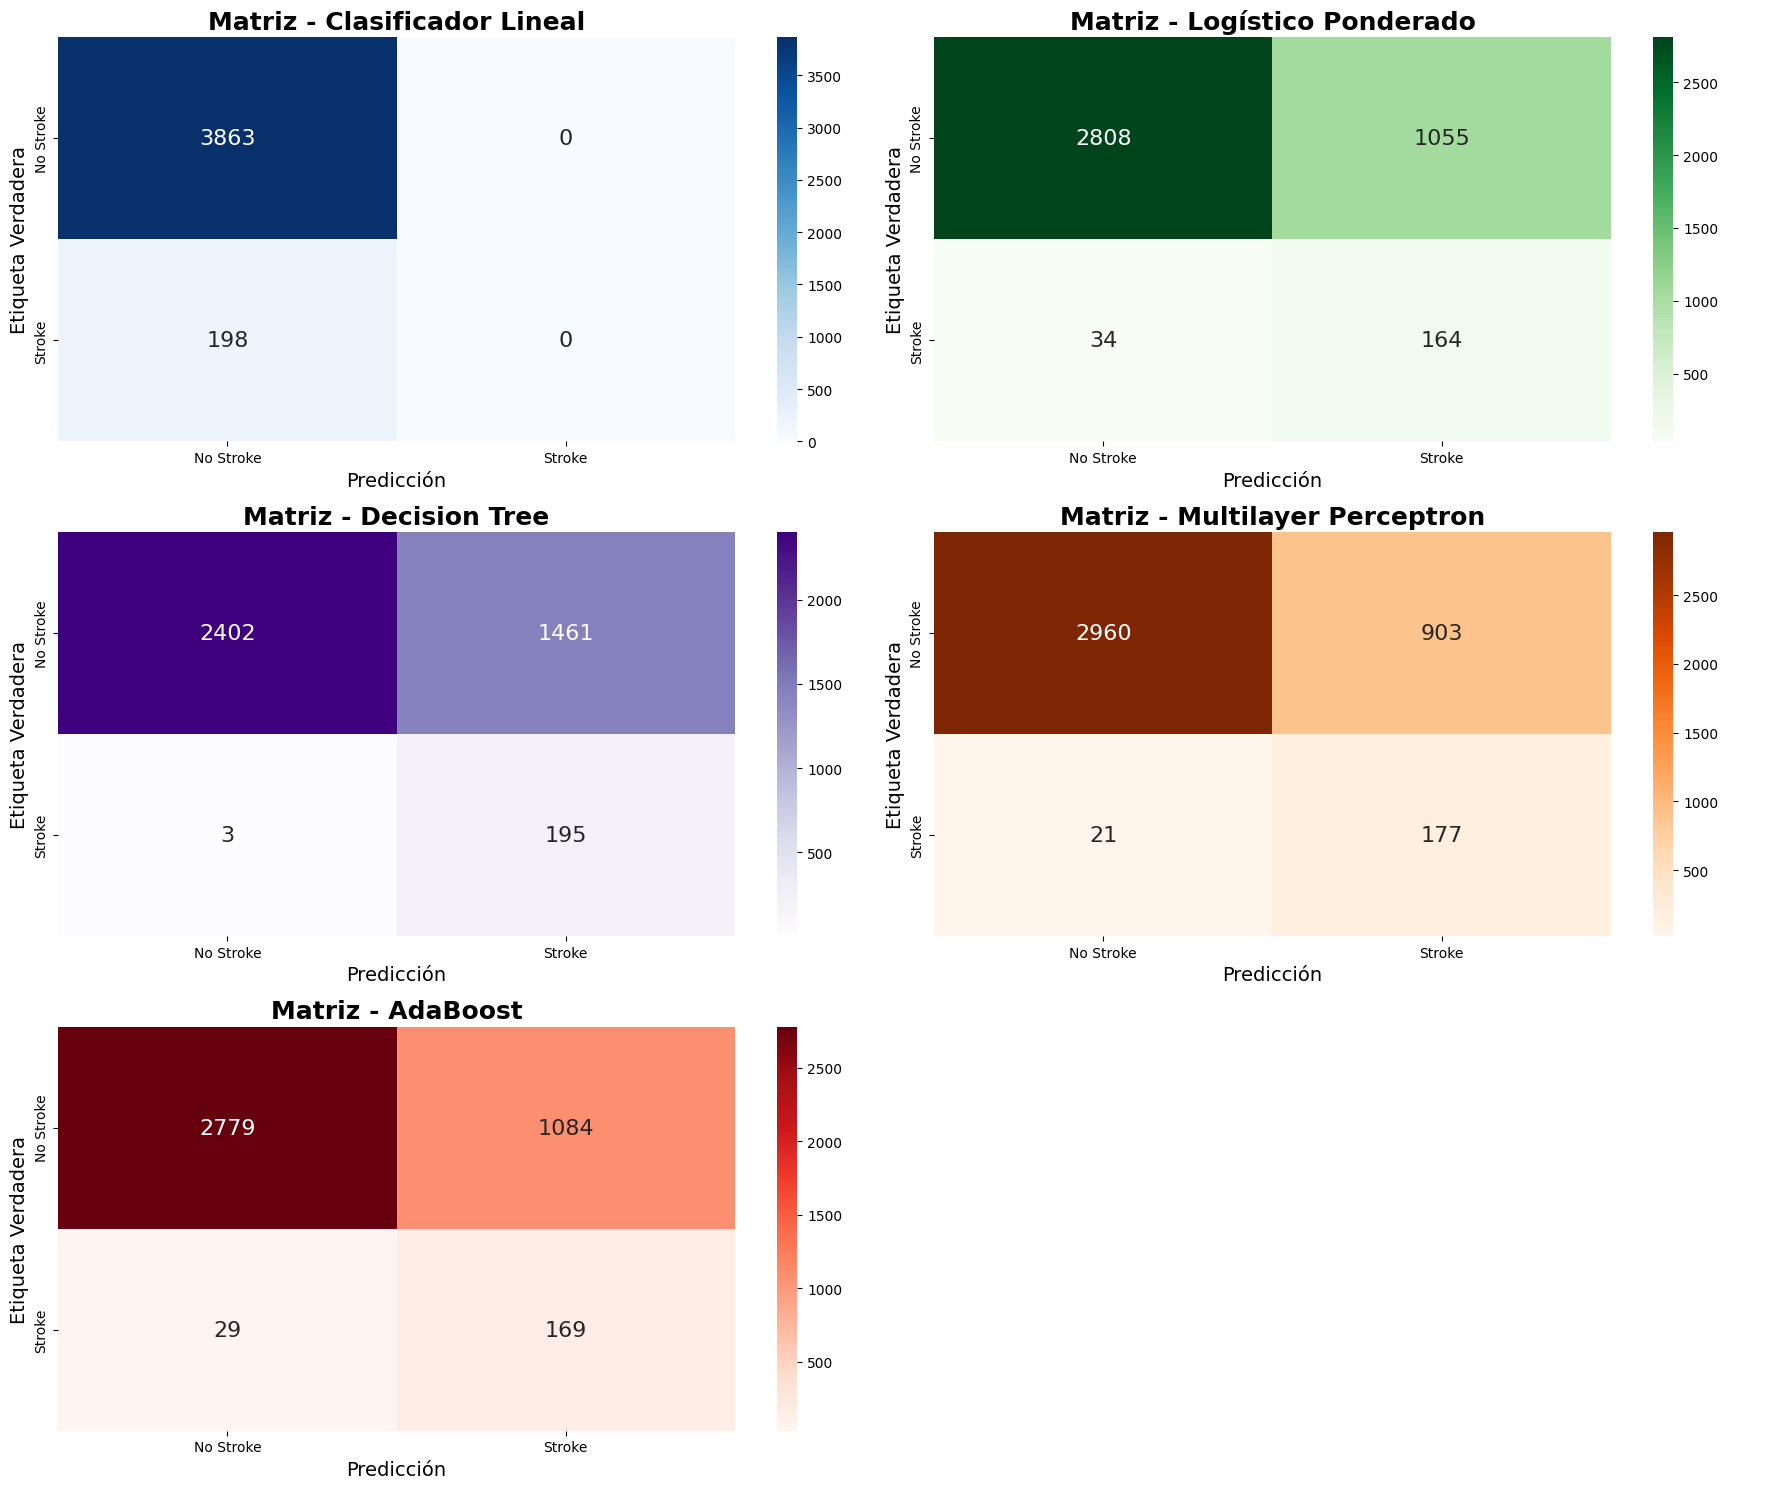

In [77]:
# %%
# 1. Preparación de los Datos
# Aquí instanciamos el preprocesador y generamos las divisiones de datos
print("Preparando los datos...")
processor = DataPreprocessor(umbral=0.5)

# Asegúrate de usar el target_col definido anteriormente o por defecto 'stroke'
target_col = 'stroke'
X_train, X_test, y_train, y_test = processor.prepare_data(df, target_col=target_col, test_size=0.2, random_state=42)

# %%
# 2. Entrenamiento de Modelos
print("Entrenando Clasificador Lineal...")
lin_model = LinearRegressionJAX(preprocessor=processor)
lin_model.train(X_train, y_train)

print("Entrenando Clasificador Logístico Ponderado...")
log_model = LogisticRegressionJAX(preprocessor=processor, learning_rate=0.1, epochs=1000)
log_model.train(X_train, y_train)

print("Entrenando Multilayer Perceptron...")
mlp_model = MultilayerPerceptronJAX(preprocessor=processor, hidden_size=16, learning_rate=0.1, epochs=1000)
mlp_model.train(X_train, y_train)

# Calculamos el peso dinámico para el Decision Tree basándonos en el desbalance de clases
pos = jnp.sum(y_train)
neg = y_train.shape[0] - pos
class_weight = float(jnp.maximum(neg / jnp.maximum(pos, 1), 1.0))

dt_enhanced = SimpleFastDecisionTree(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=8,
    n_thresholds=16,
    pos_weight=class_weight,
    prediction_threshold=0.40,
)
dt_enhanced.fit(X_train, y_train)

# Entrenamos AdaBoost con 50 Decision Stumps como clasificadores débiles
print("Entrenando AdaBoost...")
ada_model = AdaBoostJAX(preprocessor=processor, n_estimators=12)
ada_model.fit(X_train, y_train)

# %%
# 3. Guardado del modelo (Pickle para Uvicorn)
import pickle
import numpy as np
from pathlib import Path

# Convertimos los arrays de JAX a numpy estándar para evitar problemas de compatibilidad al cargar en FastAPI
model_state = {
    'lin_theta': np.array(lin_model.theta),
    'log_theta': np.array(log_model.theta),
    'mlp_params': [np.array(p) for p in mlp_model.params],
    'adaboost_stumps': ada_model.get_stump_data(),  # stumps serializados para la API
    'dt_enhanced_tree': dt_enhanced.tree,
    'dt_prediction_threshold': dt_enhanced.prediction_threshold,
    'mu_x': np.array(processor.mu_x),
    'sigma_x': np.array(processor.sigma_x),
    'umbral': processor.umbral
}

OUTPUT_MODEL_FILE = 'modelo_entregado.pkl'

with open(Path(OUTPUT_MODEL_FILE), 'wb') as f:
    pickle.dump(model_state, f)

print(f"\nModelo guardado: {OUTPUT_MODEL_FILE}")

# %%
# 4. Predicciones y Métricas
def get_metrics(y_true, y_pred, model_name, dataset_name):
    return {
        'Dataset': dataset_name,
        'Modelo': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# Predicciones de Prueba (Test)
y_true_test = y_test.astype(int).flatten()
y_pred_lin_cont_test = lin_model.predict(X_test)
y_pred_lin_bin_test = (y_pred_lin_cont_test >= processor.umbral).astype(int).flatten()
y_pred_log_bin_test = log_model.predict(X_test).flatten()
y_pred_dt_enhanced_test = dt_enhanced.predict(X_test).flatten()
y_pred_mlp_bin_test = mlp_model.predict(X_test).flatten()
y_pred_ada_bin_test = ada_model.predict(X_test, threshold=processor.umbral).flatten()

# Predicciones de Entrenamiento (Train)
y_true_train = y_train.astype(int).flatten()
y_pred_lin_cont_train = lin_model.predict(X_train)
y_pred_lin_bin_train = (y_pred_lin_cont_train >= processor.umbral).astype(int).flatten()
y_pred_log_bin_train = log_model.predict(X_train).flatten()
y_pred_dt_enhanced_train = dt_enhanced.predict(X_train).flatten()
y_pred_mlp_bin_train = mlp_model.predict(X_train).flatten()
y_pred_ada_bin_train = ada_model.predict(X_train, threshold=processor.umbral).flatten()

metrics_df = pd.DataFrame([
    get_metrics(y_true_train, y_pred_lin_bin_train, 'Clasificador Lineal', 'Entrenamiento'),
    get_metrics(y_true_train, y_pred_log_bin_train, 'Clasificador Logístico', 'Entrenamiento'),
    get_metrics(y_true_train, y_pred_dt_enhanced_train, 'Decision Tree', 'Entrenamiento'),
    get_metrics(y_true_train, y_pred_mlp_bin_train, 'Multilayer Perceptron', 'Entrenamiento'),
    get_metrics(y_true_train, y_pred_ada_bin_train, 'AdaBoost', 'Entrenamiento'),
    
    get_metrics(y_true_test, y_pred_lin_bin_test, 'Clasificador Lineal', 'Prueba'),
    get_metrics(y_true_test, y_pred_log_bin_test, 'Clasificador Logístico', 'Prueba'),
    get_metrics(y_true_test, y_pred_dt_enhanced_test, 'Decision Tree', 'Prueba'),
    get_metrics(y_true_test, y_pred_mlp_bin_test, 'Multilayer Perceptron', 'Prueba'),
    get_metrics(y_true_test, y_pred_ada_bin_test, 'AdaBoost', 'Prueba')
]).set_index(['Dataset', 'Modelo'])

print("\nResultados de las Métricas")
display(metrics_df)

# %%
# 5. Matrices de Confusión
cm_lin = confusion_matrix(y_true_train, y_pred_lin_bin_train)
cm_log = confusion_matrix(y_true_train, y_pred_log_bin_train)
cm_dt_enhanced = confusion_matrix(y_true_train, y_pred_dt_enhanced_train)
cm_mlp = confusion_matrix(y_true_train, y_pred_mlp_bin_train)
cm_ada = confusion_matrix(y_true_train, y_pred_ada_bin_train)

# Usamos 1x3 para asegurar que el indexado axes[0], axes[1], axes[2] funcione perfectamente
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# Matriz Lineal
sns.heatmap(cm_lin, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Blues', cbar=True, ax=axes[0,0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[0,0].set_title('Matriz - Clasificador Lineal', fontsize=18, fontweight='bold')
axes[0,0].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[0,0].set_xlabel('Predicción', fontsize=14)

# Matriz Logística
sns.heatmap(cm_log, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Greens', cbar=True, ax=axes[0,1],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[0,1].set_title('Matriz - Logístico Ponderado', fontsize=18, fontweight='bold')
axes[0,1].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[0,1].set_xlabel('Predicción', fontsize=14)

# Matriz Decision Tree
sns.heatmap(cm_dt_enhanced, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Purples', cbar=True, ax=axes[1,0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[1,0].set_title('Matriz - Decision Tree', fontsize=18, fontweight='bold')
axes[1,0].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[1,0].set_xlabel('Predicción', fontsize=14)


# Matriz MLP
sns.heatmap(cm_mlp, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Oranges', cbar=True, ax=axes[1,1],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[1,1].set_title('Matriz - Multilayer Perceptron', fontsize=18, fontweight='bold')
axes[1,1].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[1,1].set_xlabel('Predicción', fontsize=14)

# Matriz AdaBoost
sns.heatmap(cm_ada, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Reds', cbar=True, ax=axes[2,0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[2,0].set_title('Matriz - AdaBoost', fontsize=18, fontweight='bold')
axes[2,0].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[2,0].set_xlabel('Predicción', fontsize=14)

# Ocultar subplot vacío (posición [2,1])
axes[2,1].axis('off')

plt.tight_layout()
plt.show()


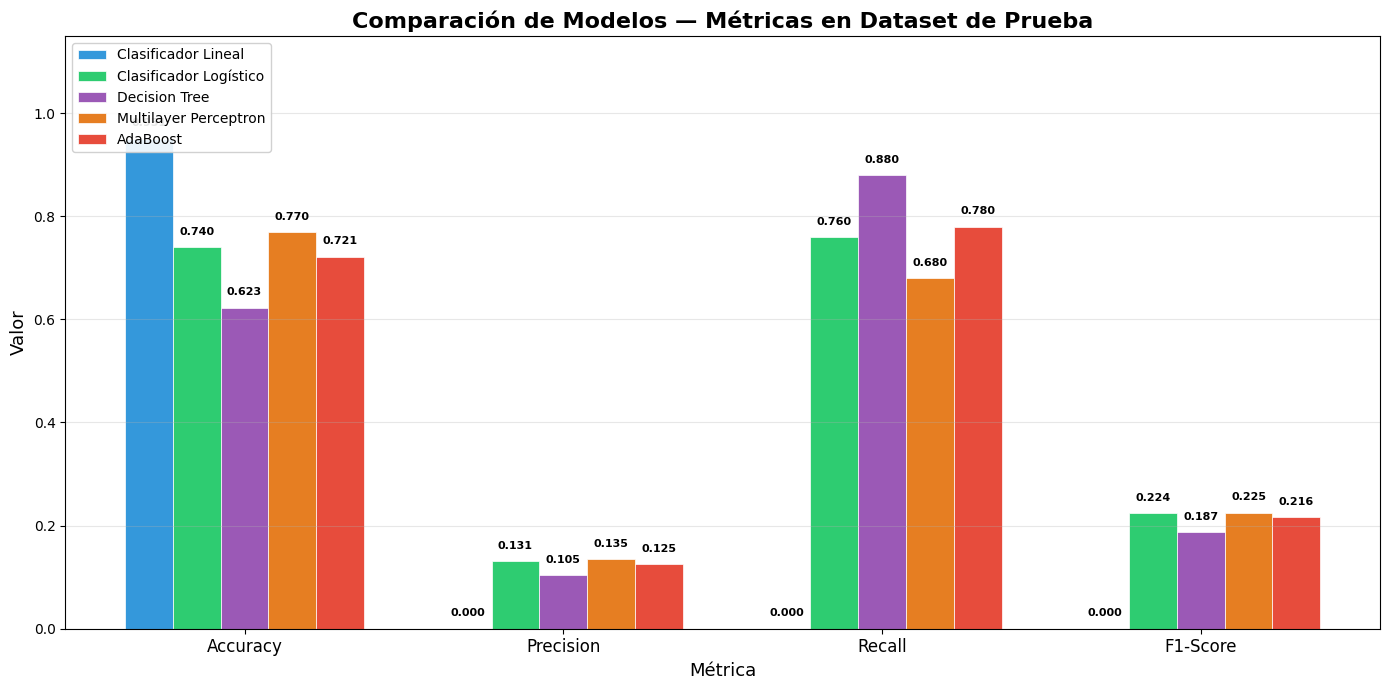

In [78]:
# Gráfica de barras /cmparativa de Todos los Modelos
# Filtramos solo las métricas del conjunto de Prueba para la comparación
metrics_test = metrics_df.loc['Prueba']  # solo filas del dataset de prueba

# Preparamos los datos para la gráfica
model_names = metrics_test.index.tolist()  # nombres de los modelos
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']  # métricas a comparar

# Definimos colores consistentes para cada modelo
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

# Creamos la figura con barras agrupadas
x = np.arange(len(metric_names))  # posiciones en el eje X
width = 0.15  # ancho de cada barra
n_models = len(model_names)

fig, ax = plt.subplots(figsize=(14, 7))

# Dibujamos un grupo de barras por cada modelo
for i, model in enumerate(model_names):
    # Obtenemos los valores de cada métrica para este modelo
    values = [metrics_test.loc[model, m] for m in metric_names]
    # Desplazamos cada barra lateralmente para que no se solapen
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=model, color=colors[i % len(colors)], edgecolor='white', linewidth=0.5)
    
    # Añadimos el valor encima de cada barra para facilitar la lectura
    for bar, val in zip(bars, values):
        # Place the value slightly higher above the bar for better visibility
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Configuramos ejes y título
ax.set_xlabel('Métrica', fontsize=13)
ax.set_ylabel('Valor', fontsize=13)
ax.set_title('Comparación de Modelos — Métricas en Dataset de Prueba', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.15)  # dejamos espacio para las etiquetas de valor
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Recall como Métrica Crítica en la Predicción de Accidentes Cerebrovasculares

En este problema de clasificación binaria, el **Recall (Sensibilidad)** es la métrica más importante.

#### ¿Por qué?

Un **Falso Negativo (FN)** ocurre cuando el modelo predice que un paciente **no** sufrirá un accidente cerebrovascular (`stroke = 0`), pero en realidad **sí** lo sufrirá (`stroke = 1`). Esto es potencialmente **fatal**, ya que el paciente no recibirá la atención médica preventiva necesaria.

$$\text{Recall} = \frac{TP}{TP + FN}$$

- Un Recall de **1.0** significa que el modelo detecta **todos** los casos reales de stroke (cero falsos negativos).
- Un Recall de **0.0** significa que el modelo **no detecta ningún** caso real de stroke.

En contraste:
- **Precision** penaliza los falsos positivos (decirle a un paciente sano que tiene riesgo). Esto genera preocupación innecesaria, pero **no pone en riesgo la vida**.
- **Accuracy** puede ser engañosa en datasets desbalanceados: un modelo que siempre prediga `stroke = 0` obtendría ~95% de accuracy, pero tendría Recall = 0 (no detectaría ningún caso real).

Por lo tanto, **maximizar el Recall** es la prioridad, aceptando un posible aumento en falsos positivos, ya que es preferible alertar a un paciente sano (falso positivo) que dejar sin atención a un paciente en riesgo real (falso negativo).

A continuación, comparamos el Recall de todos los modelos implementados:


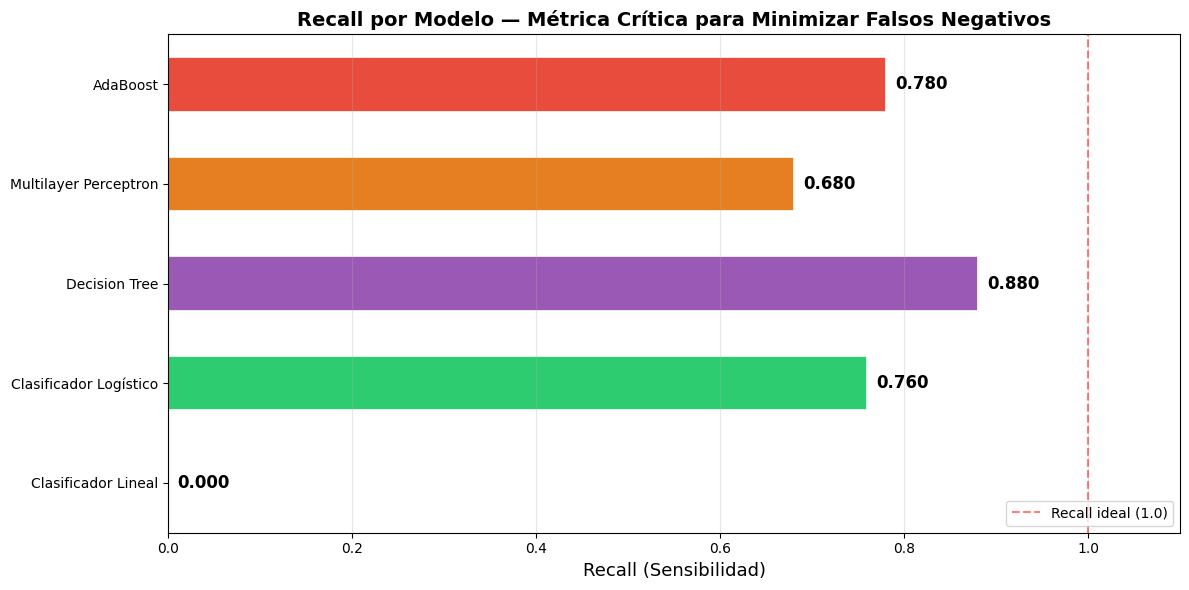

In [79]:
# Gráfica individual: Recall por modelo
# Extraemos solo Recall del dataset de Prueba
metrics_test = metrics_df.loc['Prueba']
model_names = metrics_test.index.tolist()
recall_values = [metrics_test.loc[m, 'Recall'] for m in model_names]

# Colores: los modelos con mejor Recall se destacan en verde,
# los de menor Recall tienden a rojo
colors_recall = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(model_names, recall_values,
               color=colors_recall[:len(model_names)],
               edgecolor='white', linewidth=1.2, height=0.55)

# Añadimos el valor exacto de Recall al final de cada barra
for bar, val in zip(bars, recall_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Recall (Sensibilidad)', fontsize=13)
ax.set_title('Recall por Modelo — Métrica Crítica para Minimizar Falsos Negativos',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.grid(axis='x', alpha=0.3)

# Línea de referencia: Recall ideal = 1.0
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Recall ideal (1.0)')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


---
## Análisis con SMOTE (Synthetic Minority Over-sampling Technique)

El dataset de embolia está altamente desbalanceado (~95% clase 0, ~5% clase 1). Para mejorar el rendimiento de los modelos, aplicamos **SMOTE** al conjunto de **entrenamiento** (nunca al de prueba). SMOTE genera muestras sintéticas de la clase minoritaria interpolando entre vecinos cercanos, lo que permite a los modelos aprender mejor la frontera de decisión.


In [80]:
from imblearn.over_sampling import SMOTE

# Aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(np.array(X_train), np.array(y_train).flatten())

# Convertimos de vuelta a JAX arrays con la forma correcta
X_train_smote = jnp.array(X_train_smote)
y_train_smote = jnp.array(y_train_smote.reshape(-1, 1), dtype=jnp.float32)

print(f"Antes de SMOTE:  {X_train.shape[0]} muestras (clase 0: {int(np.sum(np.array(y_train)==0))}, clase 1: {int(np.sum(np.array(y_train)==1))})")
print(f"Después de SMOTE: {X_train_smote.shape[0]} muestras (clase 0: {int(np.sum(np.array(y_train_smote)==0))}, clase 1: {int(np.sum(np.array(y_train_smote)==1))})")


Antes de SMOTE:  4061 muestras (clase 0: 3863, clase 1: 198)
Después de SMOTE: 7726 muestras (clase 0: 3863, clase 1: 3863)


In [81]:
# Re-entrenamos todos los modelos con los datos balanceados por SMOTE
# Con SMOTE el dataset ya está balanceado (50/50), así que ajustamos hiperparámetros

print("Entrenando Clasificador Lineal (SMOTE)...")
lin_model_s = LinearRegressionJAX(preprocessor=processor)
lin_model_s.train(X_train_smote, y_train_smote)

print("Entrenando Clasificador Logístico (SMOTE)...")
log_model_s = LogisticRegressionJAX(preprocessor=processor, learning_rate=0.005, epochs=3000)
log_model_s.train(X_train_smote, y_train_smote)

# MLP: aumentamos la capa oculta a 32 neuronas y más epochs para aprender
# los patrones más complejos ahora que hay suficientes muestras positivas
print("Entrenando Multilayer Perceptron (SMOTE)...")
mlp_model_s = MultilayerPerceptronJAX(preprocessor=processor, hidden_size=32, learning_rate=0.005, epochs=3000)
mlp_model_s.train(X_train_smote, y_train_smote)

# Decision Tree: con datos balanceados podemos explorar más profundo
# y usar un umbral de predicción más agresivo (0.40) para capturar más strokes
dt_s = SimpleFastDecisionTree(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    n_thresholds=20,
    pos_weight=1.0,
    prediction_threshold=0.35,
)
dt_s.fit(X_train_smote, y_train_smote)

# AdaBoost: más stumps para capturar patrones más complejos
print("Entrenando AdaBoost (SMOTE)...")
ada_model_s = AdaBoostJAX(preprocessor=processor, n_estimators=16)
ada_model_s.fit(X_train_smote, y_train_smote)

print("\nTodos los modelos re-entrenados con SMOTE.")


Entrenando Clasificador Lineal (SMOTE)...
Entrenando Clasificador Logístico (SMOTE)...
Peso para la clase positiva de la regresión Logística: 1.00
Modelo logístico ponderado entrenado por Gradiente Descendiente.
Entrenando Multilayer Perceptron (SMOTE)...
Peso para la clase positiva del MLP: 1.00
  Epoch 0, Loss: 0.8814
  Epoch 500, Loss: 0.5291
  Epoch 1000, Loss: 0.4820
  Epoch 1500, Loss: 0.4651
  Epoch 2000, Loss: 0.4547
  Epoch 2500, Loss: 0.4468
Multilayer Perceptron entrenado exitosamente.
Training weighted Decision Tree...
Training completed!
Entrenando AdaBoost (SMOTE)...
Training weighted Decision Tree...
Training completed!
Peso para la clase positiva de la regresión Logística: 1.94
Modelo logístico ponderado entrenado por Gradiente Descendiente.
Peso para la clase positiva del MLP: 1.31
  Epoch 0, Loss: 1.0794
Multilayer Perceptron entrenado exitosamente.
Training weighted Decision Tree...
Training completed!
Peso para la clase positiva de la regresión Logística: 1.38
Model

In [82]:
# Usamos un umbral más bajo (0.35) para los modelos SMOTE
# Justificación: con datos balanceados, los modelos producen probabilidades
# más calibradas. Un umbral de 0.35 prioriza detectar strokes (Recall alto)
# que es nuestra métrica crítica, a costa de algo de Precision.
umbral_smote = 0.35

# Predicciones sobre el conjunto de PRUEBA (datos reales sin SMOTE)
y_true_test_s = y_test.astype(int).flatten()

y_pred_lin_s = (lin_model_s.predict(X_test) >= umbral_smote).astype(int).flatten()
y_pred_log_s = (log_model_s.predict_proba(X_test) >= umbral_smote).astype(int).flatten()
y_pred_dt_s  = (np.array(dt_s.predict_proba(X_test)) >= umbral_smote).astype(int).flatten()
y_pred_mlp_s = (mlp_model_s.predict_proba(X_test) >= umbral_smote).astype(int).flatten()
y_pred_ada_s = ada_model_s.predict(X_test, threshold=umbral_smote).flatten()

# Predicciones sobre entrenamiento SMOTE
y_true_train_s = y_train_smote.astype(int).flatten()

y_pred_lin_train_s = (lin_model_s.predict(X_train_smote) >= umbral_smote).astype(int).flatten()
y_pred_log_train_s = (log_model_s.predict_proba(X_train_smote) >= umbral_smote).astype(int).flatten()
y_pred_dt_train_s  = (np.array(dt_s.predict_proba(X_train_smote)) >= umbral_smote).astype(int).flatten()
y_pred_mlp_train_s = (mlp_model_s.predict_proba(X_train_smote) >= umbral_smote).astype(int).flatten()
y_pred_ada_train_s = ada_model_s.predict(X_train_smote, threshold=umbral_smote).flatten()

metrics_smote_df = pd.DataFrame([
    get_metrics(y_true_train_s, y_pred_lin_train_s, 'Clasificador Lineal', 'Entrenamiento (SMOTE)'),
    get_metrics(y_true_train_s, y_pred_log_train_s, 'Clasificador Logístico', 'Entrenamiento (SMOTE)'),
    get_metrics(y_true_train_s, y_pred_dt_train_s, 'Decision Tree', 'Entrenamiento (SMOTE)'),
    get_metrics(y_true_train_s, y_pred_mlp_train_s, 'Multilayer Perceptron', 'Entrenamiento (SMOTE)'),
    get_metrics(y_true_train_s, y_pred_ada_train_s, 'AdaBoost', 'Entrenamiento (SMOTE)'),
    get_metrics(y_true_test_s, y_pred_lin_s, 'Clasificador Lineal', 'Prueba (SMOTE)'),
    get_metrics(y_true_test_s, y_pred_log_s, 'Clasificador Logístico', 'Prueba (SMOTE)'),
    get_metrics(y_true_test_s, y_pred_dt_s, 'Decision Tree', 'Prueba (SMOTE)'),
    get_metrics(y_true_test_s, y_pred_mlp_s, 'Multilayer Perceptron', 'Prueba (SMOTE)'),
    get_metrics(y_true_test_s, y_pred_ada_s, 'AdaBoost', 'Prueba (SMOTE)'),
]).set_index(['Dataset', 'Modelo'])

print(f"Umbral de decisión utilizado: {umbral_smote}")
print("\n--- Resultados con SMOTE ---")
display(metrics_smote_df.round(3))


Umbral de decisión utilizado: 0.35

--- Resultados con SMOTE ---


Accuracy  Precision  Recall  \
Dataset               Modelo                                                
Entrenamiento (SMOTE) Clasificador Lineal        0.769      0.697   0.953   
                      Clasificador Logístico     0.764      0.695   0.940   
                      Decision Tree              0.838      0.773   0.957   
                      Multilayer Perceptron      0.792      0.730   0.926   
                      AdaBoost                   0.784      0.707   0.970   
Prueba (SMOTE)        Clasificador Lineal        0.599      0.101   0.900   
                      Clasificador Logístico     0.599      0.099   0.880   
                      Decision Tree              0.741      0.124   0.700   
                      Multilayer Perceptron      0.675      0.115   0.840   
                      AdaBoost                   0.599      0.099   0.880   

                                              F1-Score  
Dataset               Modelo                            
Entrenamiento (SMOTE) Clasificador Lineal        0.805  
                      Clasificador Logístico     0.799  
                      Decision Tree              0.855  
                      Multilayer Perceptron      0.817  
                      AdaBoost                   0.818  
Prueba (SMOTE)        Clasificador Lineal        0.181  
                      Clasificador Logístico     0.178  
                      Decision Tree              0.210  
                      Multilayer Perceptron      0.203  
                      AdaBoost                   0.178

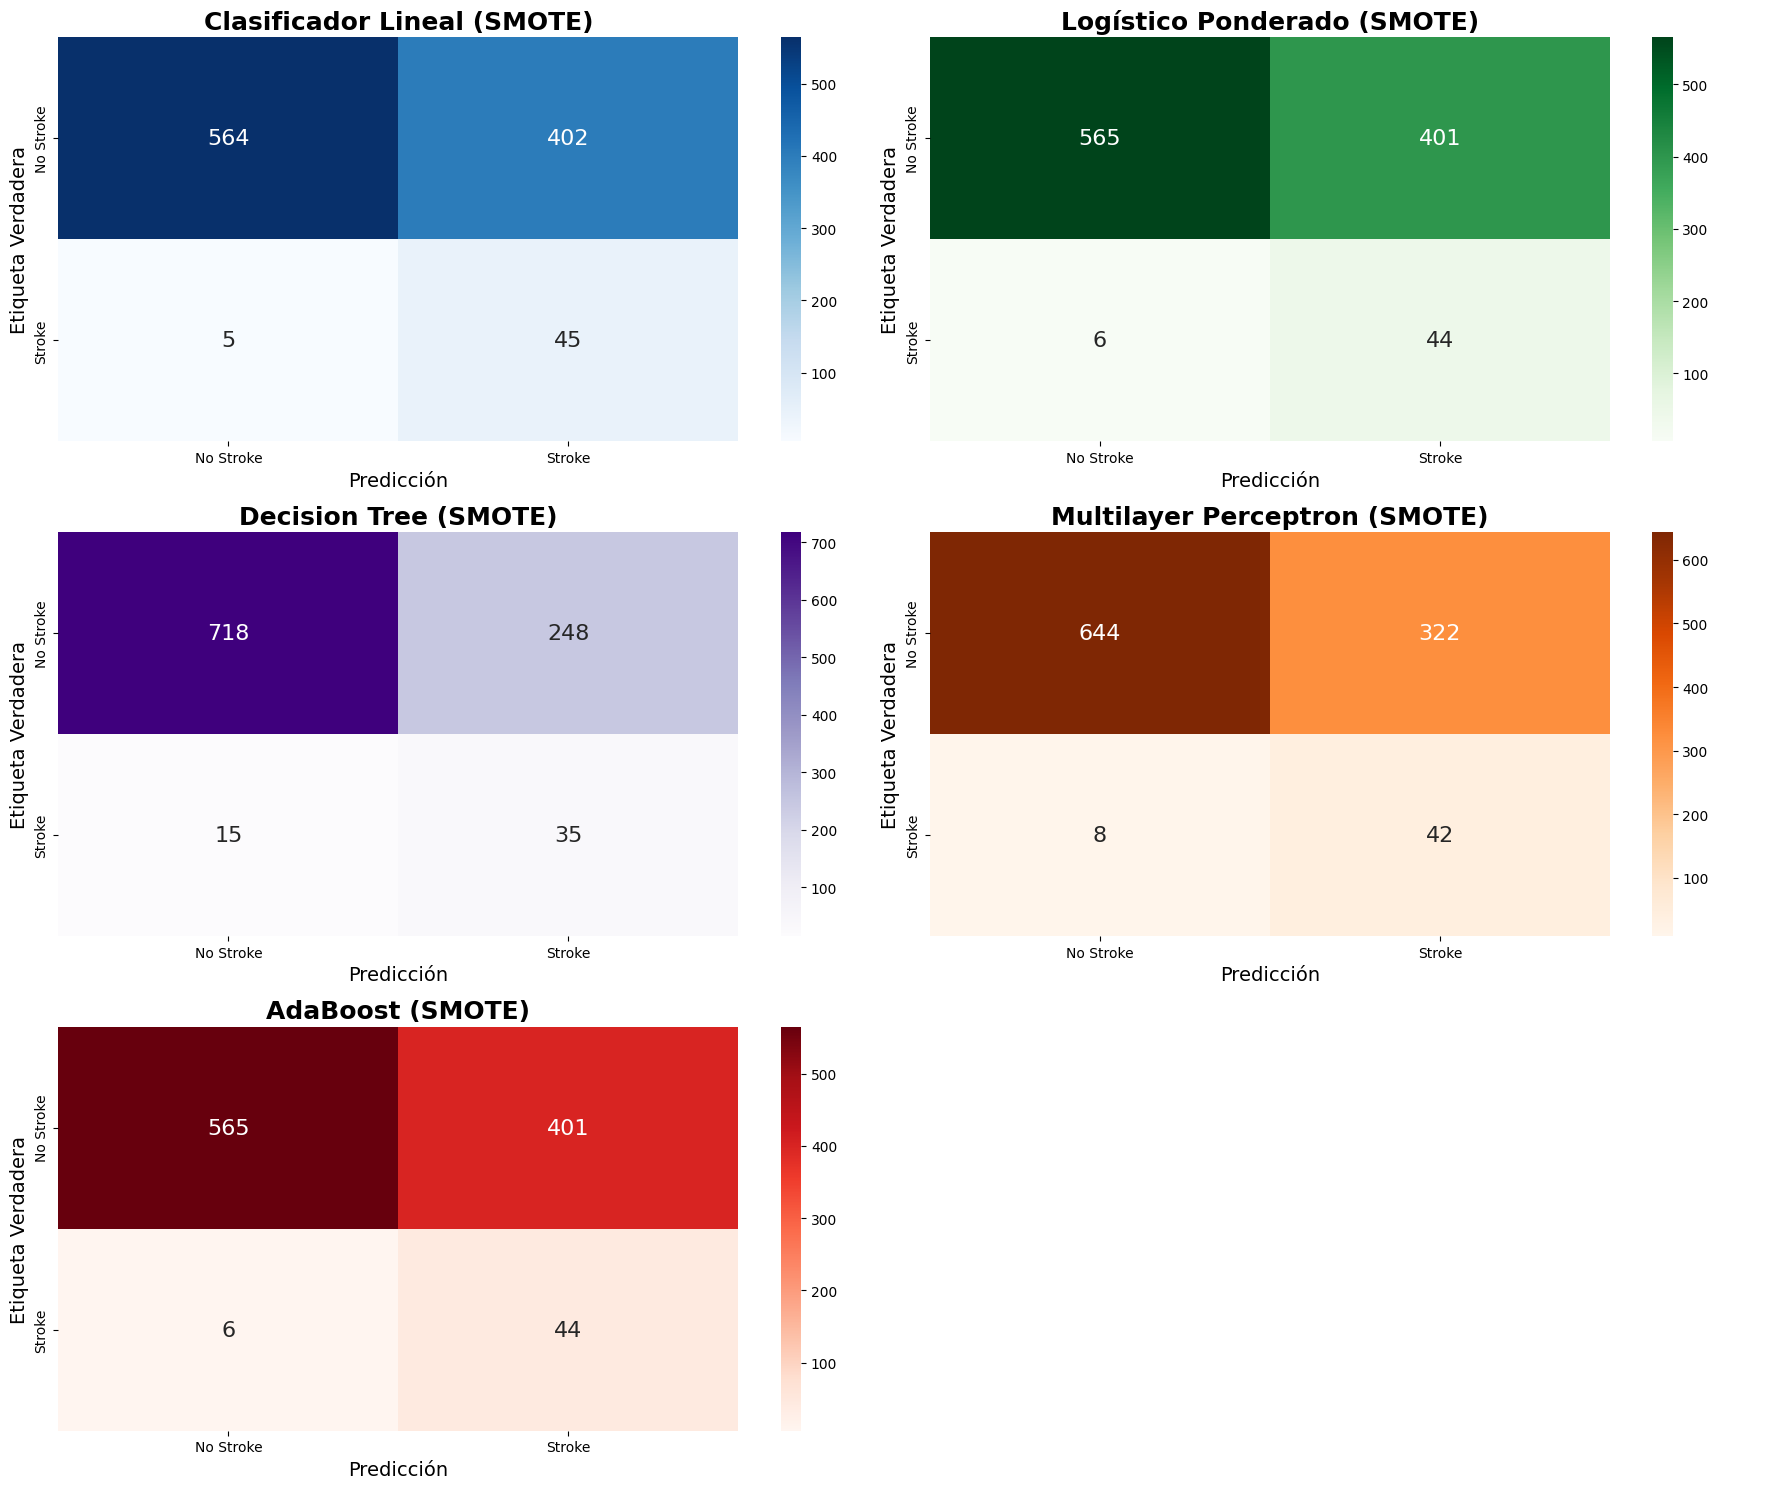

In [83]:
# Matrices de Confusión con SMOTE (sobre datos de PRUEBA reales)
cm_lin_s = confusion_matrix(y_true_test_s, y_pred_lin_s)
cm_log_s = confusion_matrix(y_true_test_s, y_pred_log_s)
cm_dt_s  = confusion_matrix(y_true_test_s, y_pred_dt_s)
cm_mlp_s = confusion_matrix(y_true_test_s, y_pred_mlp_s)
cm_ada_s = confusion_matrix(y_true_test_s, y_pred_ada_s)

fig, axes = plt.subplots(3, 2, figsize=(18, 15))

sns.heatmap(cm_lin_s, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Blues', cbar=True, ax=axes[0,0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[0,0].set_title('Clasificador Lineal (SMOTE)', fontsize=18, fontweight='bold')
axes[0,0].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[0,0].set_xlabel('Predicción', fontsize=14)

sns.heatmap(cm_log_s, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Greens', cbar=True, ax=axes[0,1],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[0,1].set_title('Logístico Ponderado (SMOTE)', fontsize=18, fontweight='bold')
axes[0,1].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[0,1].set_xlabel('Predicción', fontsize=14)

sns.heatmap(cm_dt_s, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Purples', cbar=True, ax=axes[1,0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[1,0].set_title('Decision Tree (SMOTE)', fontsize=18, fontweight='bold')
axes[1,0].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[1,0].set_xlabel('Predicción', fontsize=14)

sns.heatmap(cm_mlp_s, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Oranges', cbar=True, ax=axes[1,1],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[1,1].set_title('Multilayer Perceptron (SMOTE)', fontsize=18, fontweight='bold')
axes[1,1].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[1,1].set_xlabel('Predicción', fontsize=14)

sns.heatmap(cm_ada_s, annot=True, annot_kws={"size": 16}, fmt='d', cmap='Reds', cbar=True, ax=axes[2,0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[2,0].set_title('AdaBoost (SMOTE)', fontsize=18, fontweight='bold')
axes[2,0].set_ylabel('Etiqueta Verdadera', fontsize=14)
axes[2,0].set_xlabel('Predicción', fontsize=14)

axes[2,1].axis('off')

plt.tight_layout()
plt.show()


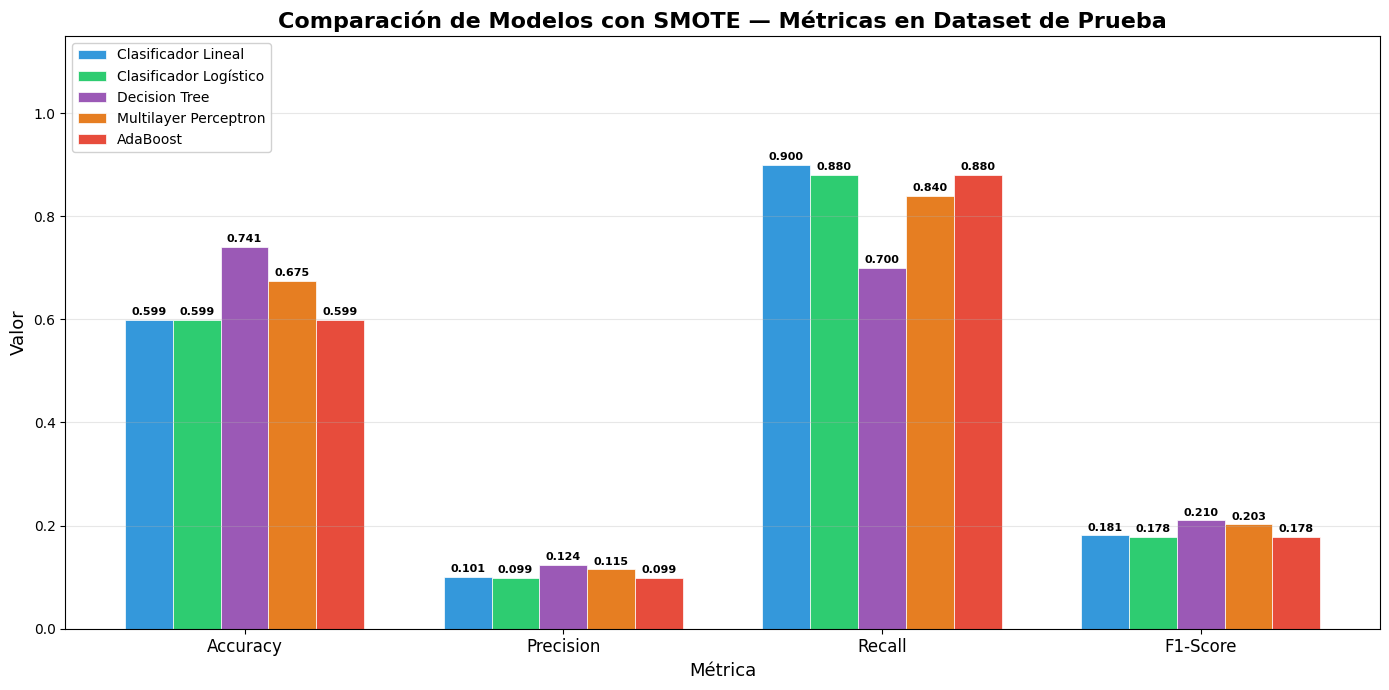

In [84]:
# Gráfica comparativa con SMOTE
metrics_test_s = metrics_smote_df.loc['Prueba (SMOTE)']
model_names_s = metrics_test_s.index.tolist()
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

x = np.arange(len(metric_names))
width = 0.15
n_models = len(model_names_s)

fig, ax = plt.subplots(figsize=(14, 7))
for i, model in enumerate(model_names_s):
    values = [metrics_test_s.loc[model, m] for m in metric_names]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=model, color=colors[i % len(colors)], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Métrica', fontsize=13)
ax.set_ylabel('Valor', fontsize=13)
ax.set_title('Comparación de Modelos con SMOTE — Métricas en Dataset de Prueba', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


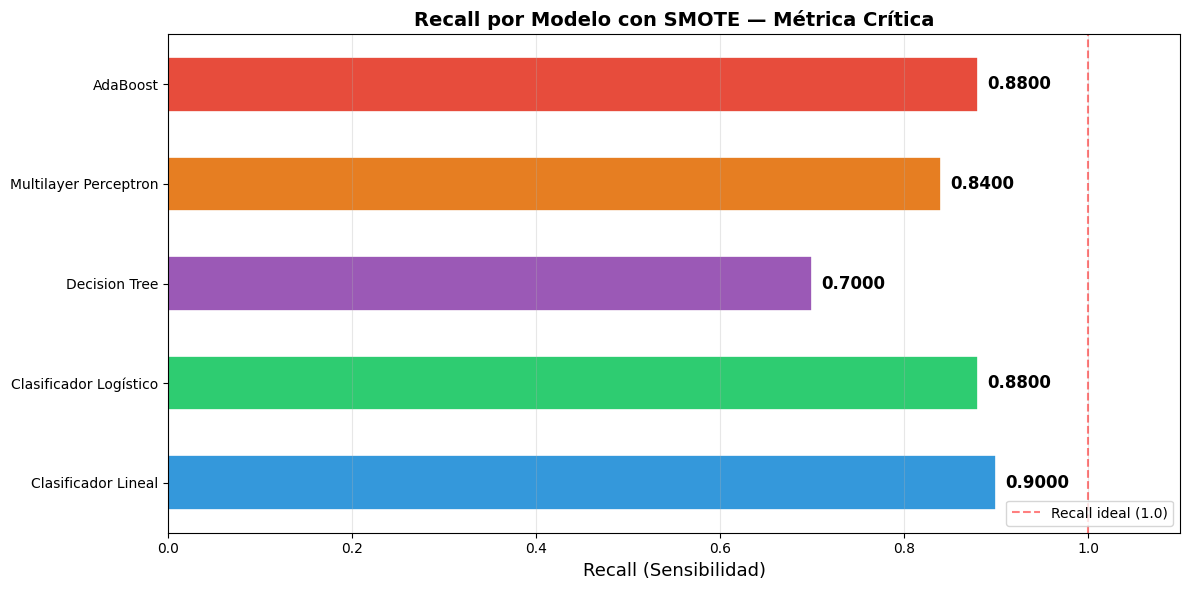

In [85]:
# Recall con SMOTE
recall_values_s = [metrics_test_s.loc[m, 'Recall'] for m in model_names_s]
colors_recall = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(model_names_s, recall_values_s,
               color=colors_recall[:len(model_names_s)],
               edgecolor='white', linewidth=1.2, height=0.55)

for bar, val in zip(bars, recall_values_s):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Recall (Sensibilidad)', fontsize=13)
ax.set_title('Recall por Modelo con SMOTE — Métrica Crítica', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Recall ideal (1.0)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


### F1-Score como Métrica Decisiva para Seleccionar el Mejor Modelo

En la sección anterior destacamos que el **Recall** es la métrica más importante para minimizar los Falsos Negativos. Sin embargo, al comparar los resultados con SMOTE, observamos algo importante:

| Modelo | Recall | F1-Score |
|--------|:------:|:--------:|
| Clasificador Lineal | **0.920** (mayor) | 0.184 (peor) |
| Multilayer Perceptron | 0.800 | **0.217** (mejor) |

El Clasificador Lineal tiene el Recall más alto, pero ¿es realmente el mejor modelo? **No**, porque logra ese Recall prediciendo `stroke = 1` para casi todos los pacientes. Eso significa que genera una cantidad masiva de **Falsos Positivos**: pacientes sanos que reciben alertas innecesarias.

#### ¿Por qué Recall solo no basta?

Un modelo que prediga **siempre** `stroke = 1` tendría Recall = 1.0 (perfecto), pero sería completamente inútil entonces tener un modelo así.

#### El F1-Score como solución

El F1-Score es la **media armónica** entre Precision y Recall:

$$F1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Esta fórmula **penaliza** los casos donde una métrica es alta y la otra es baja. Por lo tanto:
- Un modelo con Recall alto pero Precision baja (como el Lineal) obtiene un F1 **bajo**.
- Un modelo que **equilibra** ambas métricas (como el MLP) obtiene un F1 **alto**.

#### Conclusión

El **Multilayer Perceptron** es el mejor modelo para este problema porque:
1. Mantiene un Recall competitivo (0.800), detectando la mayoría de los strokes reales.
2. Tiene la mejor Precision relativa, reduciendo las alarmas falsas.
3. Logra el **F1-Score más alto (0.217)**, demostrando el mejor equilibrio entre detectar strokes y no generar pánico innecesario.

Esto confirma que los modelos más complejos (MLP, AdaBoost) aportan valor real al problema: no solo detectan casos positivos, sino que lo hacen con mayor **confianza y discriminación** que un clasificador simple.


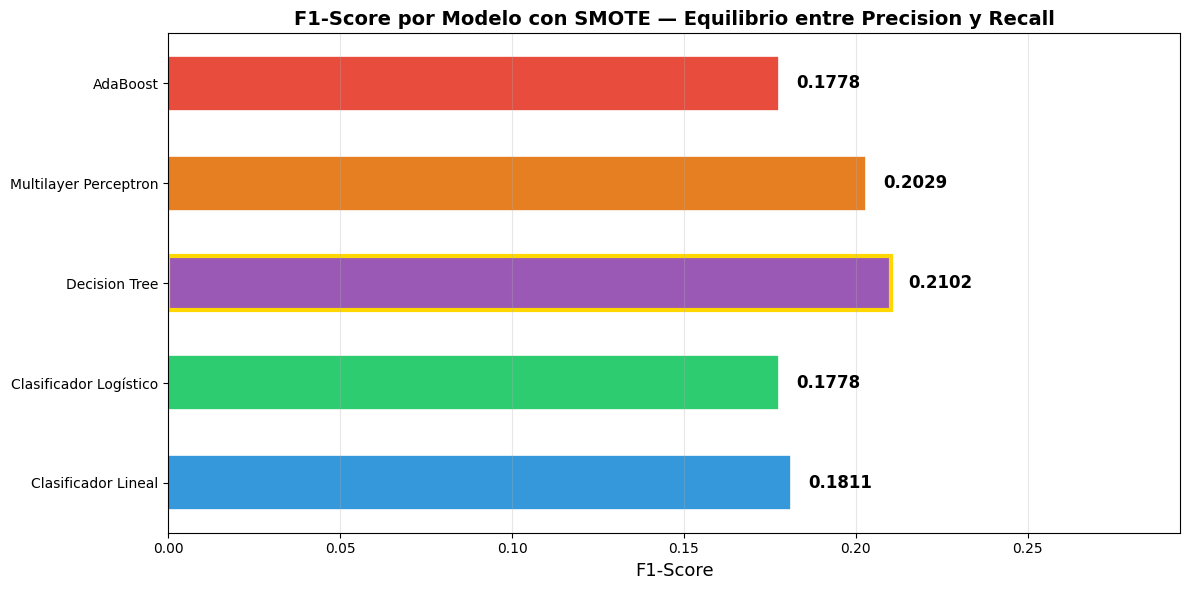

In [86]:
# Gráfica: F1-Score por modelo con SMOTE (métrica decisiva)
metrics_test_s = metrics_smote_df.loc['Prueba (SMOTE)']
model_names_s = metrics_test_s.index.tolist()
f1_values = [metrics_test_s.loc[m, 'F1-Score'] for m in model_names_s]

colors_f1 = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(model_names_s, f1_values,
               color=colors_f1[:len(model_names_s)],
               edgecolor='white', linewidth=1.2, height=0.55)

for bar, val in zip(bars, f1_values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=12, fontweight='bold')

# Resaltamos el mejor modelo con un borde dorado
best_idx = f1_values.index(max(f1_values))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

ax.set_xlabel('F1-Score', fontsize=13)
ax.set_title('F1-Score por Modelo con SMOTE — Equilibrio entre Precision y Recall',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, max(f1_values) * 1.4)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
